In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We are using device:", device)

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    # data augmentation: 1. flip horizontal 2. rotate five degrees 3. zoom 4. translate
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Settings
SAVE_PATH = '/content/drive/MyDrive/resnet18_lip_binary_weighted_weighted.pth'
EPOCHS = 20
LR = 1e-4

# map text labels to binary targets (0 = simple, 1 = complex)
LABEL_MAP = {'simple': 0.0, 'complex': 1.0}

# Dataset
class MakeupDataSet(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        image = self.transform(image)

        # CHANGED: use eye-specific binary label
        label = torch.tensor(
            LABEL_MAP[row['lips_label']],
            dtype=torch.float32
        )

        return image, label

#Load data

# CHANGED: use cropped eye images
IMG_DIR = '/content/drive/MyDrive/makeup/lip'

# CHANGED: use new region-specific binary CSV
CSV_PATH = '/content/complexity_labels_region_binary.csv'

df = pd.read_csv(CSV_PATH)
df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

missing = df[~df["image_path"].apply(os.path.exists)]

print("Missing images:", len(missing))
print(missing["filename"].tolist())

df = df[df["image_path"].apply(os.path.exists)].copy().reset_index(drop=True)

# CHANGED: use lips_label instead of complexity_label
print(df['lips_label'].value_counts())

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['lips_label']
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

train_loader = DataLoader(
    MakeupDataSet(train_df, IMG_DIR, train_tf),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    MakeupDataSet(val_df, IMG_DIR, val_tf),
    batch_size=32,
    shuffle=False
)

# -- Model --
model = models.resnet18(weights='IMAGENET1K_V1')

# output 1 raw logit for binary classification
# BCEWithLogitsLoss applies sigmoid internally
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 1)
)

# freeze everything first, then unfreeze layer4
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

# BCEWithLogitsLoss for binary classification
# Experiment 2: weighted loss
#criterion = nn.BCEWithLogitsLoss()
simple_count = (train_df['lips_label'] == 'simple').sum()
complex_count = (train_df['lips_label'] == 'complex').sum()

pos_weight = torch.tensor(
    [simple_count / complex_count],
    dtype=torch.float32
).to(device)

print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4
)

# -- Training loop --
best_val_acc = 0.0

for epoch in range(EPOCHS):

    # training phase
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    # validation phase
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)

            val_loss += criterion(outputs, labels).item() * len(labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(
                preds.squeeze(1).cpu().numpy()
            )

            all_labels.extend(
                labels.squeeze(1).cpu().numpy()
            )

    train_loss_avg = train_loss / len(train_df)
    val_loss_avg = val_loss / len(val_df)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss: {train_loss_avg:.4f} | "
        f"val_loss: {val_loss_avg:.4f} | "
        f"train_acc: {train_acc:.3f} | "
        f"val_acc: {val_acc:.3f}"
    )

    # save model if val_acc improves
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print(
            f"  -> best model saved "
            f"(val_acc={val_acc:.3f})"
        )

print(
    f"\nDone! Best validation accuracy: "
    f"{best_val_acc:.3f}"
)


Mounted at /content/drive
We are using device: cuda
Missing images: 1
['7a6efe107c6d7cdc5dd77d2af63b5bcb.png']
lips_label
simple     2042
complex     676
Name: count, dtype: int64
Training images: 2174
Validation images: 544
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


pos_weight: 3.018484354019165
Epoch 01/20 | train_loss: 1.3925 | val_loss: 1.2498 | train_acc: 0.276 | val_acc: 0.254
  -> best model saved (val_acc=0.254)
Epoch 02/20 | train_loss: 1.3399 | val_loss: 1.2761 | train_acc: 0.276 | val_acc: 0.254
Epoch 03/20 | train_loss: 1.3159 | val_loss: 1.2374 | train_acc: 0.283 | val_acc: 0.254
Epoch 04/20 | train_loss: 1.3134 | val_loss: 1.2555 | train_acc: 0.289 | val_acc: 0.256
  -> best model saved (val_acc=0.256)
Epoch 05/20 | train_loss: 1.2772 | val_loss: 1.2302 | train_acc: 0.297 | val_acc: 0.263
  -> best model saved (val_acc=0.263)
Epoch 06/20 | train_loss: 1.2588 | val_loss: 1.2093 | train_acc: 0.311 | val_acc: 0.274
  -> best model saved (val_acc=0.274)
Epoch 07/20 | train_loss: 1.2290 | val_loss: 1.2150 | train_acc: 0.310 | val_acc: 0.270
Epoch 08/20 | train_loss: 1.2088 | val_loss: 1.1983 | train_acc: 0.322 | val_acc: 0.292
  -> best model saved (val_acc=0.292)
Epoch 09/20 | train_loss: 1.1969 | val_loss: 1.1709 | train_acc: 0.350 | val

In [3]:
model.load_state_dict(
    torch.load(SAVE_PATH, map_location=device)
)

model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

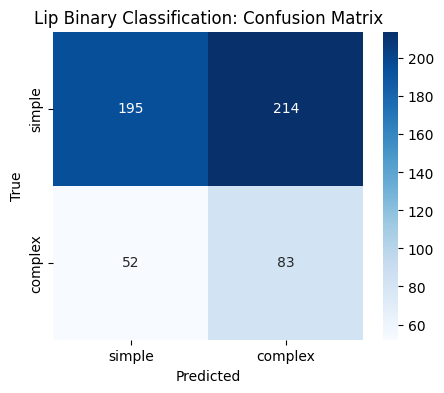

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        all_preds.extend(
            preds.squeeze(1).cpu().numpy()
        )

        all_labels.extend(
            labels.squeeze(1).cpu().numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

labels_names = [
    'simple',
    'complex'
]

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels_names,
    yticklabels=labels_names,
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Lip Binary Classification: Confusion Matrix'
)

plt.show()
